<a href="https://colab.research.google.com/github/scottspurlock/csc4422-s2026/blob/main/labs/day12_lab_spurlock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DMML Day 12 Lab: XGB and gridsearch

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

file_link = 'https://drive.google.com/uc?export=download&id=1QKmhL3OqO6Xwj2mOx03WIO7c-1IK6tcq'
columns = ['Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight', 'Rings']
df = pd.read_csv(file_link, names=columns)

df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## Clean the data to get it ready for analysis. Make sure all columns are numeric.

In [2]:
df = pd.get_dummies(df, columns=['Sex'], dtype=int)

## Make a correlation heatmap.

Text(0.5, 1.0, 'Correlation')

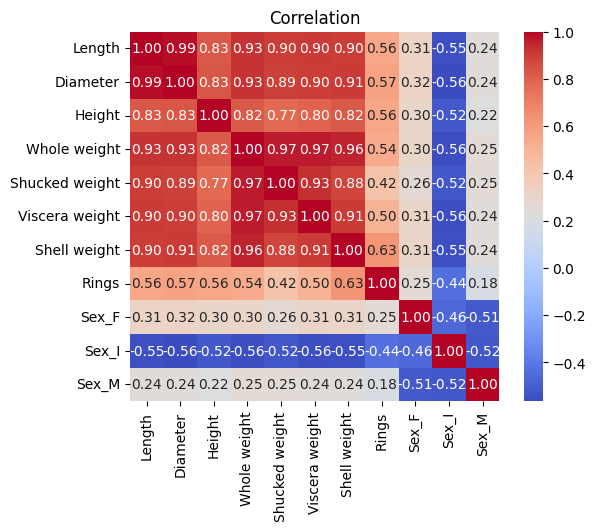

In [3]:
# from day 5...
corr = df.corr()
sns.heatmap(corr, square=True, annot=True, fmt='.2f', cbar=True, cmap="coolwarm")
plt.title('Correlation')

## Divide the data into randomized training and test partitions. Use 33% of the data
as the test set, keeping 67% for training.

In [4]:
X = df.drop(['Rings'], axis=1)
y = df['Rings']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.33, random_state=13)

## Train a XGBRegressor with n_estimators=1, max_depth=300, learning_rate=0.001

In [5]:
model = XGBRegressor(n_estimators=1, max_depth=300, learning_rate=0.001)
model.fit(Xtrain, ytrain)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.001, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=300,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1,
             n_jobs=None, num_parallel_tree=None, ...)

## Predict the test data and calculate the mean squared error (MSE) to get a baseline that we’ll try to improve by finding better hyperparameters.


In [6]:
ypred = model.predict(Xtest)
mse = mean_squared_error(ytest, ypred)
mse

10.101639747619629

Make a validation curve for the n_estimators parameter to see what a reasonable value might be for your model. Use scoring='neg_mean_squared_error' to get the validation_curve function to score models based on -MSE.

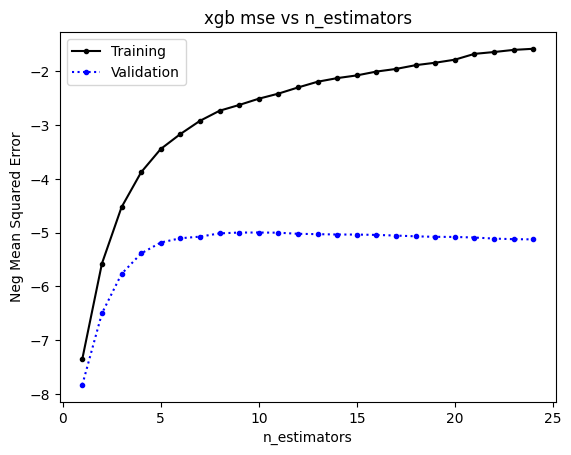

In [7]:
from sklearn.model_selection import validation_curve

trees = np.arange(1, 25)

train_scores, valid_scores = validation_curve(
    XGBRegressor(), Xtrain, ytrain,
    param_name="n_estimators", param_range=trees, cv=3, scoring='neg_mean_squared_error')

fig, ax = plt.subplots()
ax.plot(trees, train_scores.mean(axis=1), '.-k', label='Training')
ax.plot(trees, valid_scores.mean(axis=1), '.:b', label='Validation')
ax.set_xlabel('n_estimators')
ax.set_ylabel('Neg Mean Squared Error')
ax.set_title('xgb mse vs n_estimators')
ax.legend()


Do a grid search with 3-fold cross validation to find the best parameters for the XGBRegressor model. Search over a range of values for n_estimators, max_depth, and learning_rate. It may be helpful to search smaller and/or coarser ranges to start and then narrow down the best ranges (for speed).

In [11]:
# original params
# params = {
#     'n_estimators': np.arange(1, 102, 20),
#     'max_depth': np.arange(1, 18, 4),
#     'learning_rate': np.arange(0.1, 1.2, 0.2)
# }

# narrowing down
params = {
    'n_estimators': np.arange(22, 55, 4),
    'max_depth': np.arange(3, 9, 1),
    'learning_rate': np.arange(0.01, 0.12, 0.02)
}

grid = GridSearchCV(XGBRegressor(), param_grid=params, cv=3, verbose=1, scoring='neg_mean_squared_error')
grid.fit(Xtrain, ytrain)

grid.best_params_


Fitting 3 folds for each of 324 candidates, totalling 972 fits


{'learning_rate': np.float64(0.10999999999999997),
 'max_depth': np.int64(4),
 'n_estimators': np.int64(46)}

Original best params (MSE = 4.426):
- 'learning_rate': np.float64(0.1)
- 'max_depth': np.int64(5)
- 'n_estimators': np.int64(41)

New best params (MSE = 4.409):
- 'learning_rate': np.float64(0.11)
- 'max_depth': np.int64(4)
- 'n_estimators': np.int64(46)


- Train a model with the best hyperparameters you found above.
- Use your trained model to predict the labels for the test set.
- Find the MSE for your model.


In [14]:
# model = XGBRegressor(n_estimators=41, max_depth=5, learning_rate=0.1)
model = XGBRegressor(n_estimators=46, max_depth=4, learning_rate=0.11)
model.fit(Xtrain, ytrain)
ypred = model.predict(Xtest)
mse = mean_squared_error(ytest, ypred)
mse

4.409107685089111

## Feature importance

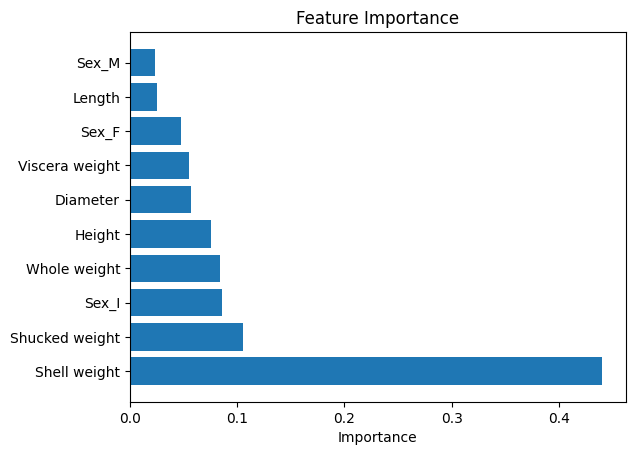

In [15]:
# Feature Importance

# Make a DataFrame for ease of sorting and visualization
feat_imp = pd.DataFrame({'Feature': X.columns,
                      'Importance': model.feature_importances_})

feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

fig, ax = plt.subplots()

# horizontal bar charts can make text easier to read
ax.barh(feat_imp['Feature'], feat_imp['Importance'])
ax.set_xlabel('Importance')
ax.set_title('Feature Importance');
